In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_score, recall_score, classification_report
from sklearn import tree, ensemble, linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from xgboost import XGBClassifier


import shap


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s4e11/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e11/train.csv
/kaggle/input/competitions/playground-series-s4e11/test.csv


# Dataset

In [3]:
data_train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/train.csv')
data_test = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/test.csv')

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [5]:
data_train.head(3)

# Dropping Name Category, obviously useless
data_train = data_train.drop(["id", "Name"], axis=1)
data_test = data_test.drop(["id", "Name"], axis=1)

In [6]:
column_numerical = list(data_train.describe(include='number').columns)
data_train.describe(include='number')

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [7]:
column_categorical = list(data_train.describe(include='object').columns)
data_train.describe(include='object')

,Gender,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
count,140700,140700,140700,104070,140700,140696,140698,140700,140700
unique,2,98,2,64,36,23,115,2,2
top,Male,Kalyan,Working Professional,Teacher,Less than 5 hours,Moderate,Class 12,No,No
freq,77464,6591,112799,24906,38784,49705,14729,71138,70758


## Exploratory Analysis

## Class Distribution

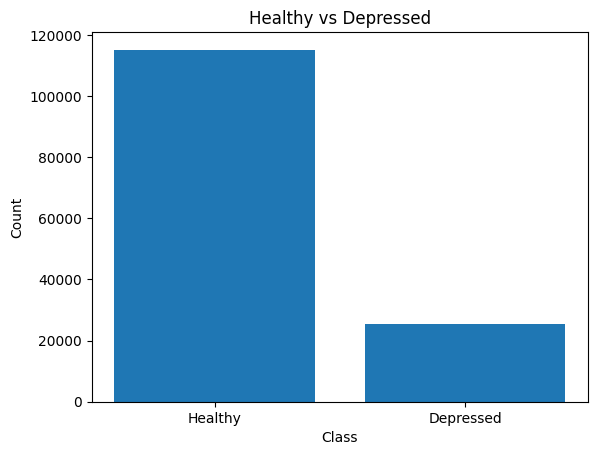

In [8]:
counts = data_train["Depression"].value_counts()
plt.bar(["Healthy", "Depressed"], counts.values)
plt.title('Healthy vs Depressed')
plt.xlabel('Class')

plt.ylabel('Count')
plt.show()
# strong class imbalance!

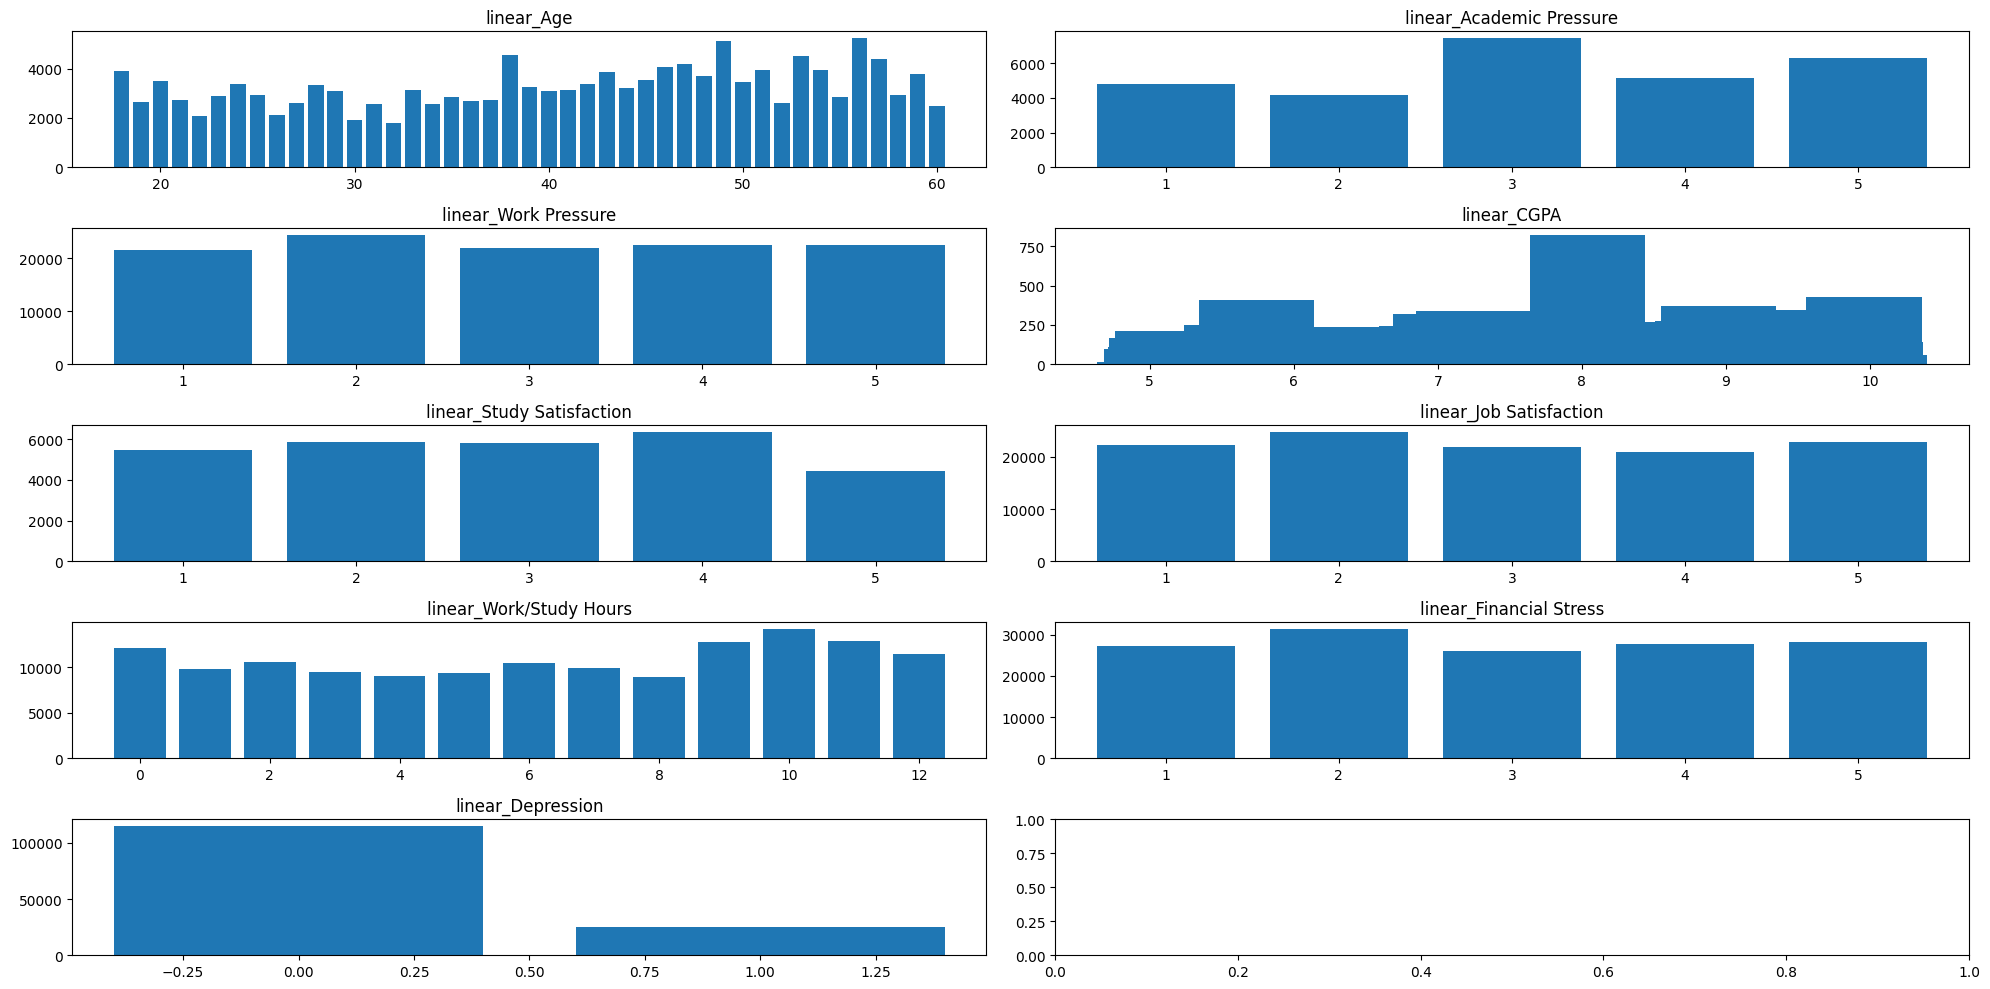

In [9]:
fig, ax = plt.subplots(5,2, figsize=(20, 10))
ax = ax.flatten()
for idx, c in enumerate(column_numerical):
    counts = data_train[c].value_counts()
    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(f"linear_{c}")

plt.tight_layout()
plt.show()
# features are uniformly distributed, no significant peaks besides CGPA

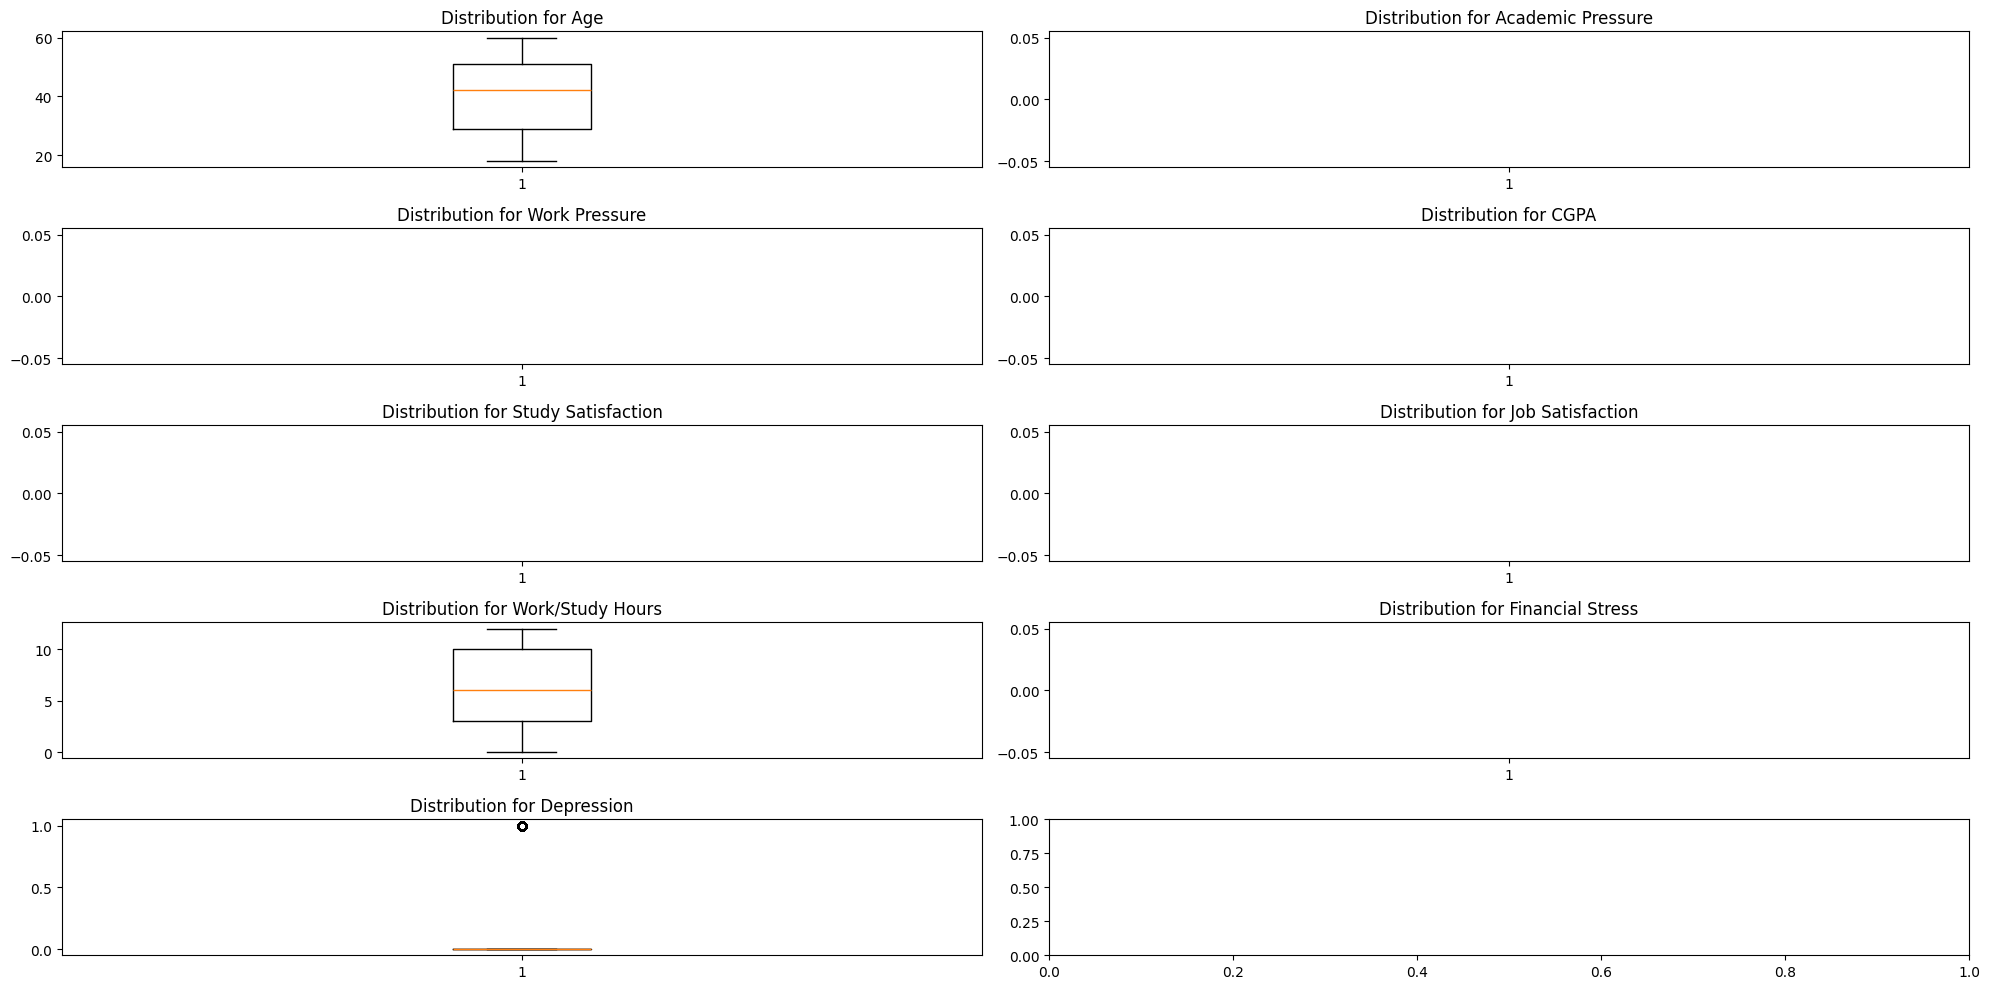

In [10]:
fig, ax = plt.subplots(5,2, figsize=(20, 10))
ax = ax.flatten()

for idx, col in enumerate(column_numerical):
    ax[idx].boxplot(x=data_train[col])
    ax[idx].set_title(f"Distribution for {col}")

plt.tight_layout()
plt.show()

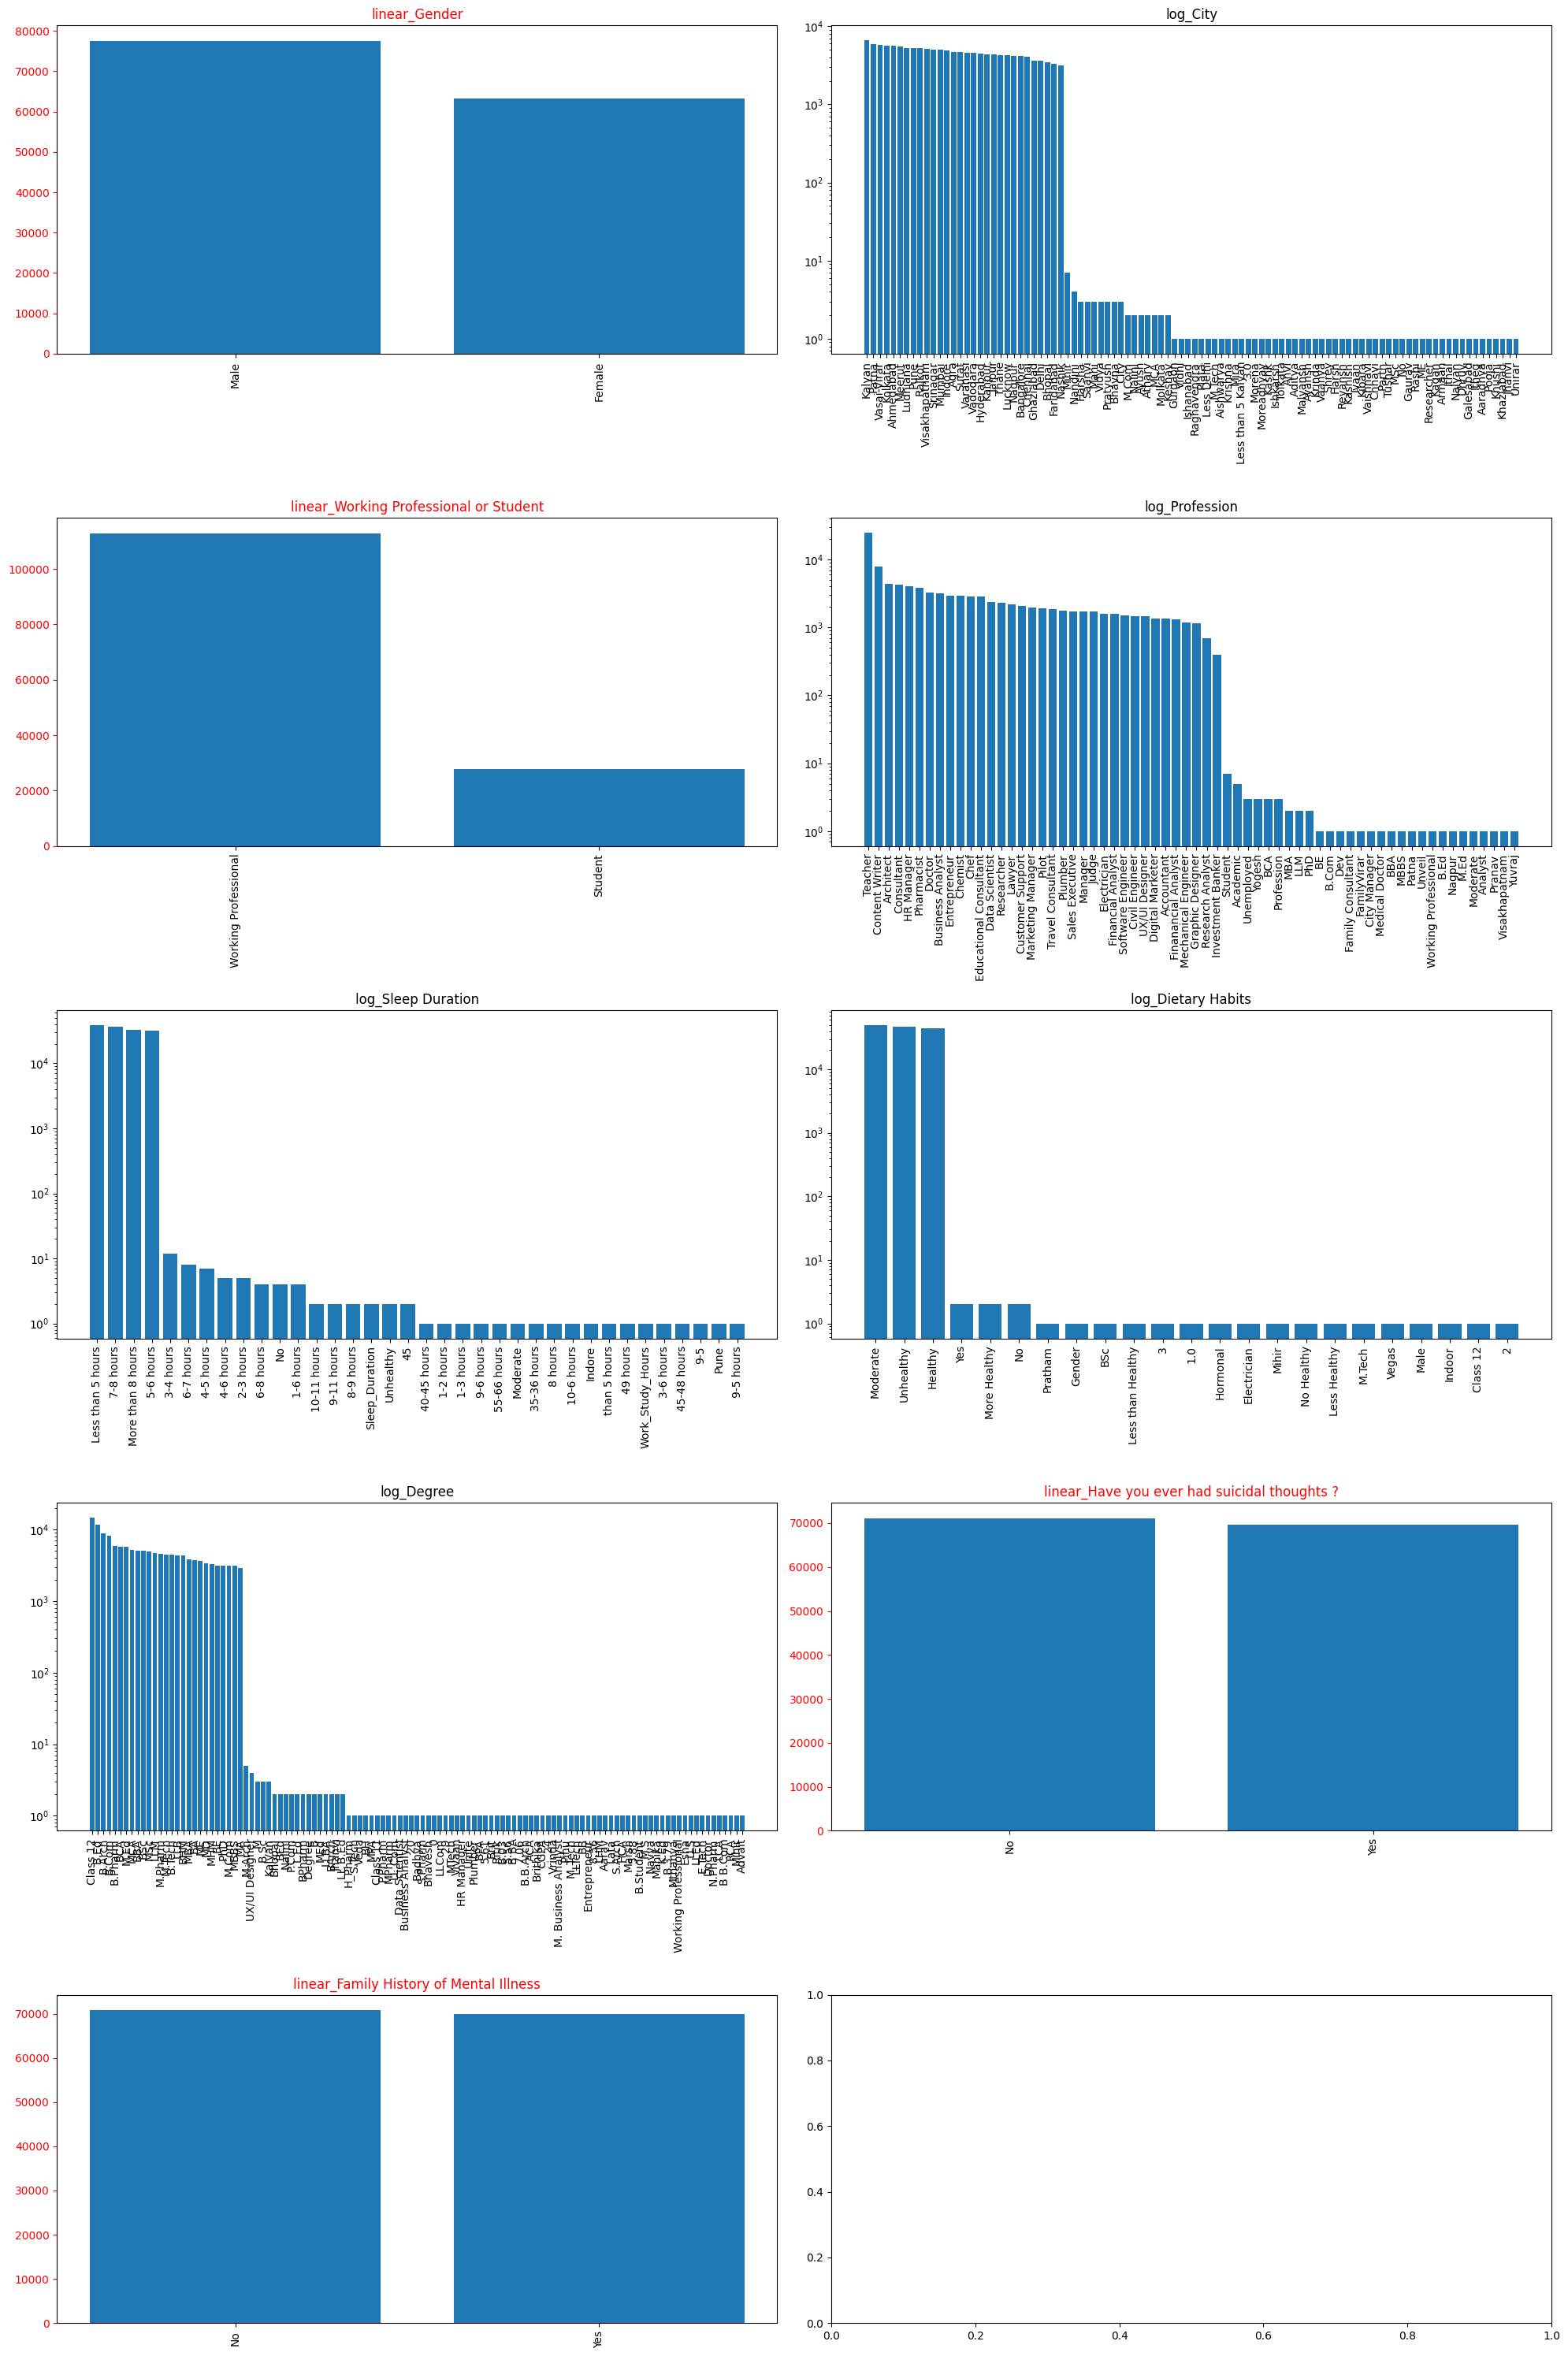

In [11]:
fig, ax = plt.subplots(5,2, figsize=(20, 30))
ax = ax.flatten()

for idx, c in enumerate(column_categorical):
    counts = data_train[c].value_counts()
    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(f"log_{c}")
    ax[idx].tick_params(axis='x', rotation=90)
    ax[idx].set_yscale("log")
    if c  in ["Gender", "Working Professional or Student", "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]:
        ax[idx].set_yscale("linear")
        ax[idx].tick_params(axis='y', colors='red')
        ax[idx].set_title(f"linear_{c}", color="red")

plt.tight_layout()
plt.show()

In [12]:
print("\nNumerical Columns")
print(column_numerical)
print("\nCategorical Columns")
print(column_categorical)


Numerical Columns
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

Categorical Columns
['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


## Handle Missing Values

In [13]:
missing_values_df = pd.DataFrame()
missing_values_df["# Missing"] = data_train.isnull().sum()
missing_values_df["% Missing"] = missing_values_df["# Missing"] / len(data_train) * 100
display(missing_values_df)

,# Missing,% Missing
Gender,0,0.000000
Age,0,0.000000
City,0,0.000000
Working Professional or Student,0,0.000000
Profession,36630,26.034115
Academic Pressure,112803,80.172708
Work Pressure,27918,19.842217
CGPA,112802,80.171997
Study Satisfaction,112803,80.172708
Job Satisfaction,27910,19.836532


In [14]:
has_academic_press = data_train['Academic Pressure'].notna()
has_work_press = data_train['Work Pressure'].notna()

has_academic_sat = data_train['Study Satisfaction'].notna()
has_work_sat = data_train['Job Satisfaction'].notna()

print("\nAcademic vs Work Pressure")
academic_only = (has_academic_press & ~has_work_press).sum()
work_only = (~has_academic_press & has_work_press).sum()
both = (has_academic_press & has_work_press).sum()
neither = (~has_academic_press & ~has_work_press).sum()

print(f"Academic Only: {academic_only}")
print(f"Work Only: {work_only}")
print(f"Both: {both}")
print(f"Neither: {neither}")

print("\nAcademic vs Work Satisfaction")
academic_only = (has_academic_sat & ~has_work_sat).sum()
work_only = (~has_academic_sat & has_work_sat).sum()
both = (has_academic_sat & has_work_sat).sum()
neither = (~has_academic_sat & ~has_work_sat).sum()

print(f"Academic Only: {academic_only}")
print(f"Work Only: {work_only}")
print(f"Both: {both}")
print(f"Neither: {neither}")



Academic vs Work Pressure
Academic Only: 27897
Work Only: 112782
Both: 0
Neither: 21

Academic vs Work Satisfaction
Academic Only: 27895
Work Only: 112788
Both: 2
Neither: 15


In [17]:
# merged pressure and satisfaction for students and working people as they complement each other
data_train["Total Pressure"] = data_train['Academic Pressure'].fillna(0) + data_train['Work Pressure'].fillna(0)
data_train["Total Satisfaction"] = data_train['Study Satisfaction'].fillna(0) + data_train['Job Satisfaction'].fillna(0)

data_test["Total Pressure"] = data_test['Academic Pressure'].fillna(0) + data_test['Work Pressure'].fillna(0)
data_test["Total Satisfaction"] = data_test['Study Satisfaction'].fillna(0) + data_test['Job Satisfaction'].fillna(0)

# replace 0 (prev both NaN) back with NaN so it can be imputed later
data_train["Total Pressure"] = data_train["Total Pressure"].replace(0, np.nan)
data_train["Total Satisfaction"] = data_train["Total Satisfaction"].replace(0, np.nan)

data_test["Total Pressure"] = data_test["Total Pressure"].replace(0, np.nan)
data_test["Total Satisfaction"] = data_test["Total Satisfaction"].replace(0, np.nan)

# clip to valid range
data_train["Total Pressure"] = data_train["Total Pressure"].clip(lower=1, upper=5)
data_train["Total Satisfaction"] = data_train["Total Satisfaction"].clip(lower=1, upper=5)

data_test["Total Pressure"] = data_test["Total Pressure"].clip(lower=1, upper=5)
data_test["Total Satisfaction"] = data_test["Total Satisfaction"].clip(lower=1, upper=5)

column_numerical.extend(["Total Pressure", "Total Satisfaction"])

In [18]:
# column_drop = list(missing_values_df[missing_values_df["% Missing"] > 40].T.columns)
column_drop = ["CGPA", "Academic Pressure", "Work Pressure", "Study Satisfaction", "Job Satisfaction"] 
print("\nTo remove due to too many missing")
print(column_drop)

column_reduced_numerical = list(filter(lambda x: x not in (column_drop + ["Depression"]), column_numerical))
print("\nRemaining Numerical")
print(column_reduced_numerical)

print("\nRemaining Categorical")
print(column_categorical)

data_train = data_train.drop(columns=column_drop)
data_test = data_test.drop(columns=column_drop)


To remove due to too many missing
['CGPA', 'Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction']

Remaining Numerical
['Age', 'Work/Study Hours', 'Financial Stress', 'Total Pressure', 'Total Satisfaction', 'Total Pressure', 'Total Satisfaction', 'Total Pressure', 'Total Satisfaction']

Remaining Categorical
['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


### Impute Missing Data

In [19]:
# don't replace with most frequent as it wouldnt make sense
data_train["Profession"] = data_train["Profession"].fillna("other")
data_test["Profession"] = data_test["Profession"].fillna("other")

imputer_numerical = SimpleImputer(strategy='mean')
data_train[column_reduced_numerical] = imputer_numerical.fit_transform(data_train[column_reduced_numerical])
data_test[column_reduced_numerical] = imputer_numerical.transform(data_test[column_reduced_numerical])

imputer_categorical = SimpleImputer(strategy='most_frequent')
data_train[column_categorical] = imputer_categorical.fit_transform(data_train[column_categorical])
data_test[column_categorical] = imputer_categorical.transform(data_test[column_categorical])

In [20]:
missing_values_df = pd.DataFrame()
missing_values_df["# Missing"] = data_train.isnull().sum()
missing_values_df["% Missing"] = missing_values_df["# Missing"] / len(data_train) * 100
display(missing_values_df)

,# Missing,% Missing
Gender,0,0.0
Age,0,0.0
City,0,0.0
Working Professional or Student,0,0.0
Profession,0,0.0
Sleep Duration,0,0.0
Dietary Habits,0,0.0
Degree,0,0.0
Have you ever had suicidal thoughts ?,0,0.0
Work/Study Hours,0,0.0


## Binning 

In [21]:
num_categories = pd.DataFrame()
num_categories["num_categories"] = data_train[column_categorical].nunique()
display(num_categories)

,num_categories
Gender,2
City,98
Working Professional or Student,2
Profession,65
Sleep Duration,36
Dietary Habits,23
Degree,115
Have you ever had suicidal thoughts ?,2
Family History of Mental Illness,2


In [22]:
threshold = 0.03 # replace classes with less than 3% of elements

for col in column_categorical:
    freq = data_train[col].value_counts()
    top_classes = freq.index[(freq.values / len(data_train)) > threshold]
    data_train.loc[~data_train[col].isin(top_classes), col] = "other"
    data_test.loc[~data_test[col].isin(top_classes), col] = "other"

In [23]:
num_categories = pd.DataFrame()
num_categories["num_categories"] = data_train[column_categorical].nunique()
display(num_categories)

,num_categories
Gender,2
City,23
Working Professional or Student,2
Profession,5
Sleep Duration,5
Dietary Habits,4
Degree,18
Have you ever had suicidal thoughts ?,2
Family History of Mental Illness,2


In [ ]:
# Skip OneHot as XGB and HGB don't require it!

# encoder_onehot= OneHotEncoder(categories='auto',handle_unknown='ignore', sparse_output=False)
# train_encoded = encoder_onehot.fit_transform(data_train[column_categorical])
# test_encoded = encoder_onehot.transform(data_test[column_categorical])

# encoded_cols = encoder_onehot.get_feature_names_out(column_categorical)

# train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=data_train.index)
# test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=data_test.index)

# data_train = pd.concat([data_train.drop(columns=column_categorical), train_encoded_df], axis=1)
# data_test = pd.concat([data_test.drop(columns=column_categorical), test_encoded_df], axis=1)


In [24]:
# convert object to category type, needed for xgb and hgb
for col in column_categorical:
    data_train[col] = data_train[col].astype('category')
    data_train[col] = data_train[col].astype('category')

In [25]:
x_train = data_train.drop('Depression', axis=1)
y_train = data_train['Depression']

x_test = data_test.copy()

In [30]:
print(x_train.columns)
print(x_test.columns)

Index(['Gender', 'Age', 'City', 'Working Professional or Student',
       'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness',
       'Total Pressure', 'Total Satisfaction'],
      dtype='object')
Index(['Gender', 'Age', 'City', 'Working Professional or Student',
       'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness',
       'Total Pressure', 'Total Satisfaction'],
      dtype='object')


In [31]:
MLA = [
    # hist allows approximate splits by binning values instead of calculating exact (much slower)
    XGBClassifier(tree_method='hist', enable_categorical=True), 
    ensemble.HistGradientBoostingClassifier(max_iter=100, categorical_features=column_categorical)
]

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mla_results = []
fitted_models = {}


for row_idx, alg in enumerate(MLA):
    MLA_name = alg.__class__.__name__
    print(f"Current model: {MLA_name}")

    cv_results = cross_validate(alg, x_train, y_train, cv=strat_kfold,return_train_score=True)

    mla_results.append({
        'MLA Name': MLA_name,
        'MLA Parameters': str(alg.get_params()),
        'MLA Train Accuracy Mean': cv_results['train_score'].mean(),
        'MLA Val Accuracy Mean': cv_results['test_score'].mean(),
        'MLA Time': cv_results['fit_time'].mean()
    })
    
    alg.fit(x_train, y_train)
    fitted_models[MLA_name] = alg

MLA_compare = pd.DataFrame(mla_results)
MLA_compare.sort_values(by=['MLA Val Accuracy Mean'], ascending=False, inplace=True)
display(MLA_compare)

Current model: XGBClassifier
Current model: HistGradientBoostingClassifier


,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Val Accuracy Mean,MLA Time
1,HistGradientBoostingClassifier,"{'categorical_features': ['Gender', 'City', 'W...",0.944838,0.938714,1.393735
0,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.959538,0.936311,0.854248


# Submission 1:
**Score: 0.94157**

In [47]:
submission = pd.DataFrame()

model = fitted_models.get("HistGradientBoostingClassifier")
y_pred_numeric = model.predict(x_test)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission.to_csv("submission_hgb_v1.csv", index=False)

In [ ]:
# TODO Precision Recall

# Feature Analysis

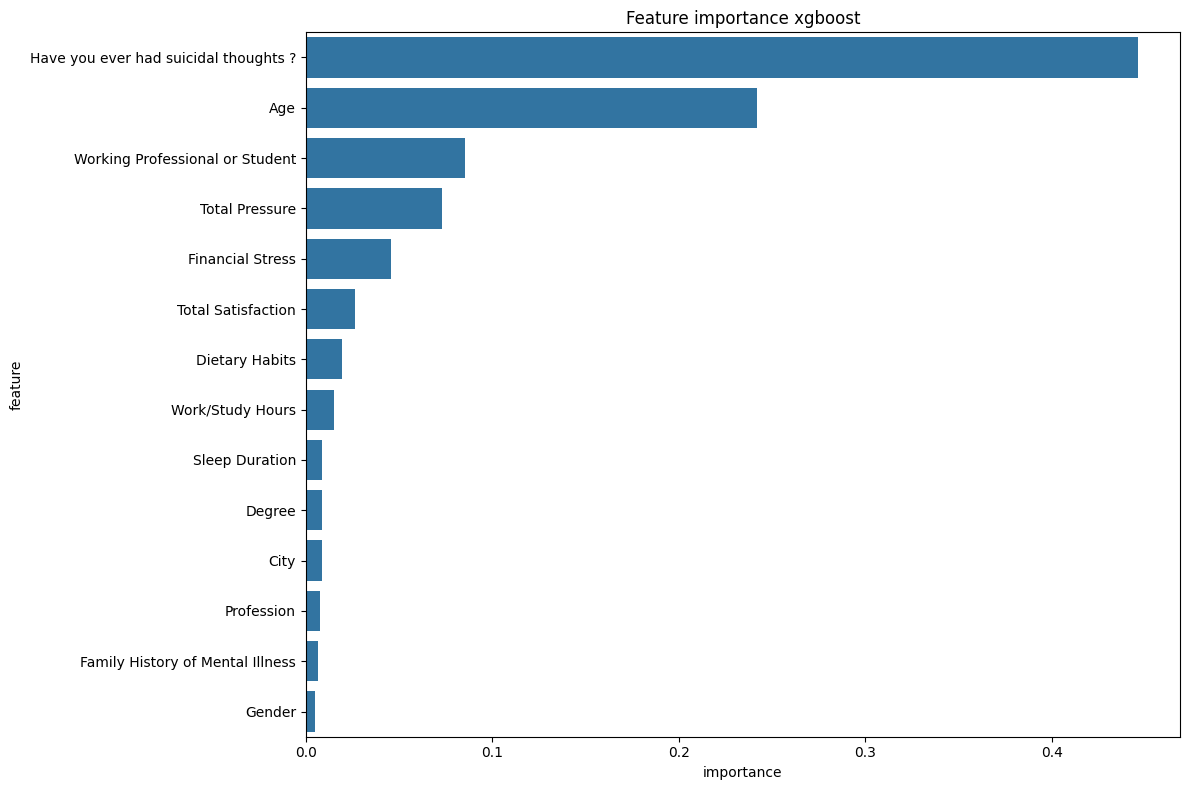

In [33]:
xgb_model = fitted_models.get("XGBClassifier")

importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance XGBClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


importance_xgb_columns = importance_df['feature'][:20]

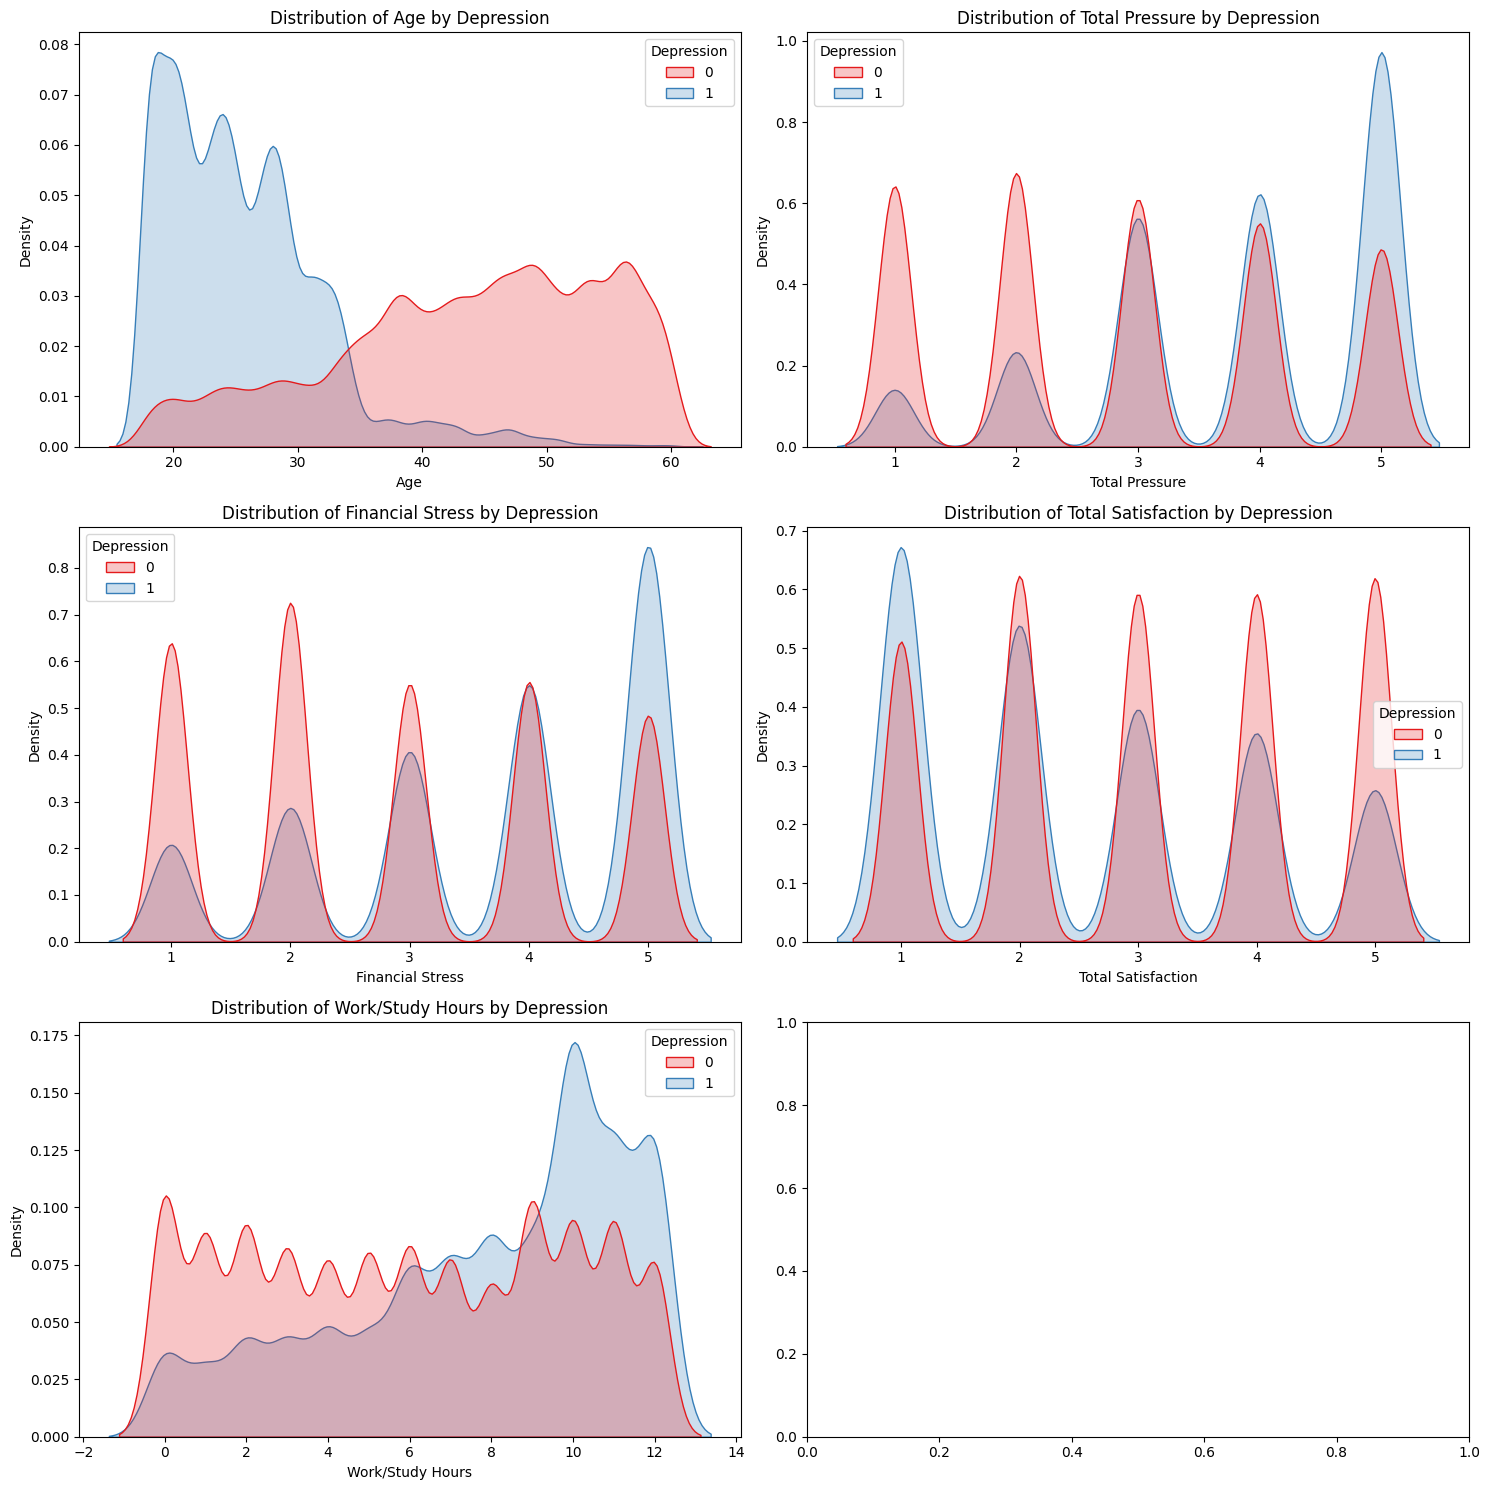

In [45]:
features = ['Age', 'Total Pressure', 'Financial Stress', 'Total Satisfaction', "Work/Study Hours"]

fig, ax = plt.subplots(3,2, figsize=(15, 15))
ax = ax.flatten() 

for i, feature in enumerate(features):
    sns.kdeplot(
        data=data_train, 
        x=feature, 
        hue='Depression', 
        fill=True, 
        common_norm=False, 
        palette='Set1',
        ax=ax[i] 
    )
    ax[i].set_title(f"Distribution of {feature} by Depression")
    ax[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

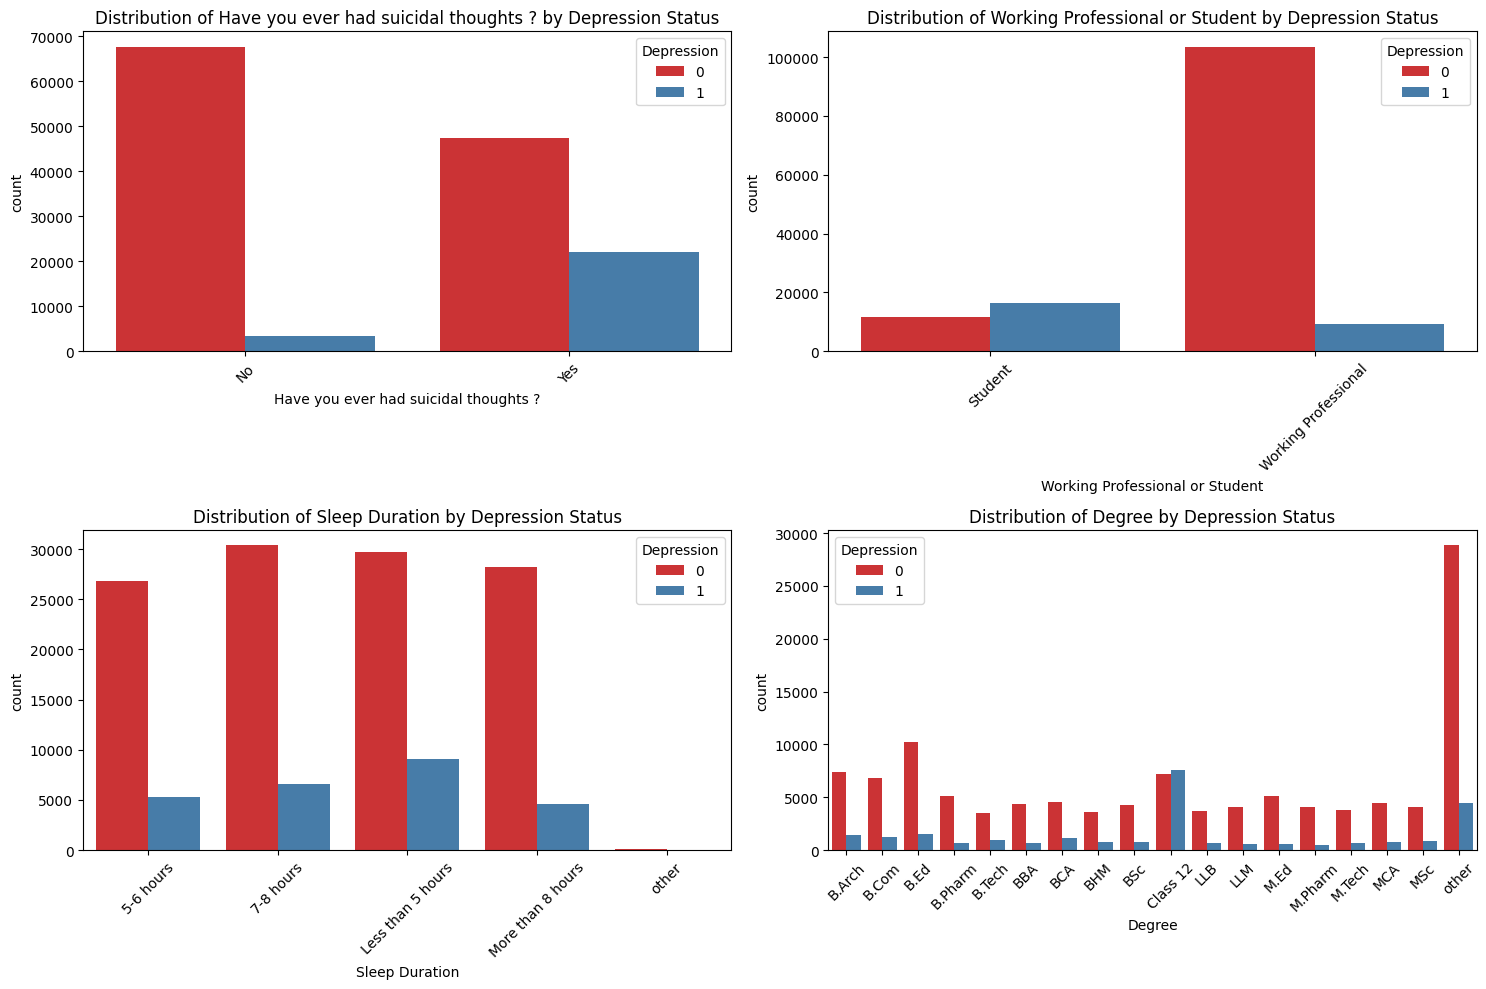

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Have you ever had suicidal thoughts ?', 'Working Professional or Student','Sleep Duration', 'Degree' ]

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

for i, feature in enumerate(features):
    sns.countplot(
        data=data_train, 
        x=feature, 
        hue='Depression', 
        palette='Set1', 
        ax=ax[i]
    )
    
    ax[i].set_title(f"Distribution of {feature} by Depression Status")
    ax[i].set_xlabel(feature)
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
# put sleep duration into relation for the tree => otherwise just strings, now e.g. 5-6 similar to less than 5
sleep_mapping = {
    '7-8 hours': 0,      
    'More than 8 hours': 1,
    '5-6 hours': 2,
    'Less than 5 hours': 3 
}

data_train['Sleep_Risk_Score'] = data_train['Sleep Duration'].map(sleep_mapping)
data_test['Sleep_Risk_Score'] = data_test['Sleep Duration'].map(sleep_mapping)

column_numerical.append('Sleep_Risk_Score')

In [ ]:
# TODO